# Graph Convolutional Networks (GCN)

In [1]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    # Clone your repository if it hasn't been cloned yet
    if not os.path.exists('/content/svi-fema-spatial-graph-modeling'):
        !git clone https://github.com/AnhJoe/svi-fema-spatial-graph-modeling.git
    
    # Change working directory to the project root
    os.chdir('/content/svi-fema-spatial-graph-modeling')

In [2]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [3]:
# Standard libraries
import joblib
from pathlib import Path

# Third-party libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Local imports
from src.gcn import (
    GCNRegressor,
    build_gcn_support,
    build_optimizer,
    count_parameters,
    evaluate_regression,
    evaluate_regression_per_target,
    get_device,
    history_to_dataframe,
    make_masks,
    numpy_to_torch_features_targets,
    predict_gcn,
    results_dict_to_frame,
    run_gcn_experiment,
    set_seed,
    stack_split_arrays,
    summarize_graph,
    train_gcn,
)

# Global configuration
SEED = 42

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.frameon": True,
        "legend.borderpad": 0.3,
    }
)

In [4]:
#| output: false

# Data directories
RAW_DATA_DIR = root / "data" / "raw"
ARTIFACTS_DIR = root / "data" / "artifacts"
PROCESSED_DATA_DIR = root / "data" / "processed"
SVI_PATH = RAW_DATA_DIR / "SVI_2018_US_county.csv"
SHAPE_PATH = RAW_DATA_DIR / "tl_2018_us_county/tl_2018_us_county.shp"


# Load county geometries (used later for graph construction and spatial diagnostics)
geo_df = gpd.read_file(PROCESSED_DATA_DIR / "svi_counties.gpkg", layer="counties").copy()

# Ensure FIPS formatting is consistent
geo_df["FIPS"] = geo_df["FIPS"].astype(str).str.zfill(5)

# Load processed split arrays
data = np.load(PROCESSED_DATA_DIR / "svi_processed_splits.npz", allow_pickle=True)

# Log feature pipeline
Xlog_train_scaled = data["Xlog_train_scaled"]
Xlog_val_scaled = data["Xlog_val_scaled"]
Xlog_test_scaled = data["Xlog_test_scaled"]

# Targets
ylog_train_scaled = data["ylog_train_scaled"]
ylog_val_scaled = data["ylog_val_scaled"]
ylog_test_scaled = data["ylog_test_scaled"]

# County identifiers (used for alignment and diagnostics)
fips_train = pd.Series(data["fips_train"]).astype(str).str.zfill(5).to_numpy()
fips_val = pd.Series(data["fips_val"]).astype(str).str.zfill(5).to_numpy()
fips_test = pd.Series(data["fips_test"]).astype(str).str.zfill(5).to_numpy()

# Load scalers (needed to invert predictions later)
scaler_Xlog = joblib.load(PROCESSED_DATA_DIR / "scaler_Xlog.pkl")
scaler_ylog = joblib.load(PROCESSED_DATA_DIR / "scaler_ylog.pkl")

# Concatenate all nodes in modeling order
fips_all = np.concatenate([fips_train, fips_val, fips_test])
X_all = np.vstack([Xlog_train_scaled, Xlog_val_scaled, Xlog_test_scaled])
y_all = np.vstack([ylog_train_scaled, ylog_val_scaled, ylog_test_scaled])

In [5]:
#| output: false

# Basic split and shape checks
assert Xlog_train_scaled.shape[0] == len(fips_train)
assert Xlog_val_scaled.shape[0] == len(fips_val)
assert Xlog_test_scaled.shape[0] == len(fips_test)

assert ylog_train_scaled.shape[0] == len(fips_train)
assert ylog_val_scaled.shape[0] == len(fips_val)
assert ylog_test_scaled.shape[0] == len(fips_test)

assert X_all.shape[0] == len(fips_all)
assert y_all.shape[0] == len(fips_all)

# Check for duplicate FIPS before graph construction
assert pd.Index(fips_all).is_unique
assert pd.Index(geo_df["FIPS"]).is_unique

# Check coverage before reindexing
missing_in_geo = sorted(set(fips_all) - set(geo_df["FIPS"]))
assert len(missing_in_geo) == 0

# Reorder geometry to exact node order for graph construction
geo_graph = geo_df.set_index("FIPS").loc[fips_all].copy()

# Alignment assertions
assert len(geo_graph) == len(fips_all) == X_all.shape[0] == y_all.shape[0]
assert np.array_equal(geo_graph.index.to_numpy(), fips_all)

# Final geometry integrity checks
assert geo_graph.index.is_unique
assert not geo_graph.index.isna().any()
assert geo_graph.geometry.notna().all()

# Alignment diagnostic
alignment_summary = pd.DataFrame(
    {
        "Quantity": [
            "Train counties",
            "Validation counties",
            "Test counties",
            "Total modeled counties",
            "geo_graph counties",
            "Feature columns",
            "Target columns",
        ],
        "Value": [
            len(fips_train),
            len(fips_val),
            len(fips_test),
            len(fips_all),
            len(geo_graph),
            X_all.shape[1],
            y_all.shape[1] if y_all.ndim > 1 else 1,
        ],
    }
)

display(alignment_summary.style.hide(axis="index"))

Quantity,Value
Train counties,2198
Validation counties,471
Test counties,472
Total modeled counties,3141
geo_graph counties,3141
Feature columns,15
Target columns,1


In [8]:
#| output: false

# Load best MLP results
mlp_config_df = pd.read_csv(ARTIFACTS_DIR / "final_mlp_results.csv", index_col=0)

display(mlp_config_df.T)

Model,MLP
Feature Pipeline,Log-Transformed Features
Architecture,Deep-128
Hidden Dimensions,"[128, 64, 32]"
Dropout,0.1
Weight Decay,0.00001
Learning Rate,0.001
Trainable Parameters,12417
Epochs Trained,46
Best Epoch,21
Best Validation Loss,0.459419


## Model Motivation

The GCN model treats counties as dependent observations with neighboring counties that share regional socioeconomic conditions, infrastructure systems, hazard exposure, and policy contexts. A graph-based model can explicitly incorporate this spatial dependence by representing counties as nodes and geographic adjacency as edges, allowing the model to combine local tabular features with information from nearby counties. The goal of the GCN is therefore to evaluate whether explicit spatial structure improves prediction compared to the tabular MLP baseline. Graph-based learning approaches provide a principled framework for modeling relationships in network-structured data (Hamilton, 2020).

## Model Formulation

Let $G = (V,E)$ denote a graph where each node $i \in V$ represents a county and edges $(i,j) \in E$ represent spatial adjacency defined using **Queen contiguity**. Let $X \in \mathbb{R}^{n \times p}$ denote the matrix of county-level predictors (log-transformed SVI indicators) and $y \in \mathbb{R}^{n}$ denote the log-transformed FEMA assistance target.

A Graph Convolutional Network updates node representations by combining each node’s features with aggregated information from its neighbors (Kipf & Welling, 2017). A typical GCN layer is

$$
H^{(\ell + 1)} =
\sigma
\left(
\tilde{D}^{-1/2}
\tilde{A}
\tilde{D}^{-1/2}
H^{(\ell)}
W^{(\ell)}
\right)
$$

where

- $H^{(0)} = X$
- $\tilde{A} = A + I$ is the adjacency matrix with self-loops
- $\tilde{D}$ is the corresponding degree matrix
- $W^{(\ell)}$ is a trainable weight matrix
- $\sigma(\cdot)$ is a nonlinear activation function

This formulation allows the model to propagate information across neighboring counties while learning node-level representations from both local features and spatial context (Hamilton, 2020).

The final layer produces predictions

$$
\hat{y} \in \mathbb{R}^{n}
$$

and the model is trained by minimizing **mean squared error (MSE)** on the training nodes.

## Training Configuration

Following the similar preprocessing and evaluation setup as the MLP to ensure fair comparison, the GCN is trained using the following optimization and training settings prior to the ablation experiments:

* **Feature representation:** only `log1p(ihp)`
* **Number of graph convolution layers:** 1
* **Hidden dimension:** 64
* **Optimizer:** Adam
* **Learning rate:** 1e-3
* **Weight decay (L2 regularization):** 1e-5
* **Dropout:** 0.1
* **Maximum training epochs:** 300
* **Early stopping patience:** 25 epochs
* **Loss function:** Mean Squared Error (MSE)
* **Activation function:** ReLU

## Ablation Plan

The GCN experiments focus on three design dimensions: graph depth, hidden representation size, and regularization strength. Each dimension is varied independently while the others remain fixed, mirroring the ablation strategy used in the MLP stage.

* **Number of GCN Layers:** 1, 2, 3
* **Hidden dimension:** 32, 64, 128
* **Regularization:**
    * **Weight decay:** 0, 1e-5, 1e-3
    * **Dropout:** 0, 0.1, 0.3

In [9]:
#| label: tbl-split-summary
#| tbl-cap: "Shapes of the processed train, validation, and test arrays used for GCN modeling."
#| output: false

# Data validation
split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "X Shape": [
            Xlog_train_scaled.shape,
            Xlog_val_scaled.shape,
            Xlog_test_scaled.shape,
        ],
        "y Shape": [
            ylog_train_scaled.shape,
            ylog_val_scaled.shape,
            ylog_test_scaled.shape,
        ],
    }
)

display(split_summary.style.hide(axis="index"))

Split,X Shape,y Shape
Train,"(2198, 15)","(2198, 1)"
Validation,"(471, 15)","(471, 1)"
Test,"(472, 15)","(472, 1)"


In [10]:
#| label: tbl-geo-summary
#| tbl-cap: "Basic summary of the county geometry used to construct the spatial graph."
#| output: false

# Data validation
geo_summary = pd.DataFrame(
    {
        "Metric": [
            "Number of counties",
            "Number of columns",
            "CRS",
            "Node order aligned to splits",
        ],
        "Value": [
            len(geo_graph),
            geo_graph.shape[1],
            str(geo_graph.crs),
            np.array_equal(geo_graph.index.to_numpy(), fips_all),
        ],
    }
)

display(geo_summary.style.hide(axis="index"))

Metric,Value
Number of counties,3141
Number of columns,124
CRS,EPSG:4269
Node order aligned to splits,True


In [11]:
#| label: tbl-queen-graph-summary
#| tbl-cap: "Summary of the Queen contiguity graph constructed from county geometries."
#| output: false

set_seed(SEED)

# Build graph support using the geometry already aligned to fips_all order
adjacency_raw, adjacency_norm, adjacency_torch, queen_w = build_gcn_support(
    geo_df=geo_graph,
    id_column=None,
    add_loops=True,
    use_index=True,
)

graph_summary = summarize_graph(adjacency_raw)
display(graph_summary.style.hide(axis="index"))

c:\Users\joetn\anaconda3\envs\svi\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
 There are 3 islands with ids: 15007, 15003, 15001.
  W.__init__(self, neighbors, ids=ids, **kw)


n_nodes,n_edges_undirected,degree_min,degree_mean,degree_median,degree_max,n_isolated_nodes
3141,9277,0.000000,5.907036,6.000000,14.000000,3


In [12]:
# Stack arrays in train -> val -> test order
X_all, y_all, train_idx, val_idx, test_idx, node_order, split_ids, split_sizes = stack_split_arrays(
    X_train=Xlog_train_scaled,
    X_val=Xlog_val_scaled,
    X_test=Xlog_test_scaled,
    y_train=ylog_train_scaled,
    y_val=ylog_val_scaled,
    y_test=ylog_test_scaled,
)

# Create boolean masks that identify which graph nodes belong to each split
train_mask, val_mask, test_mask = make_masks(
    n_nodes=X_all.shape[0],
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

In [13]:
# Select the computation device
device = get_device()

# Convert the stacked feature and target arrays to PyTorch tensors
X_t, y_t = numpy_to_torch_features_targets(X_all, y_all, device=device)

# Move graph objects and masks to the same device
adjacency_torch = adjacency_torch.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

assert X_t.shape[0] == adjacency_torch.shape[0] == adjacency_torch.shape[1]
assert y_t.shape[0] == X_t.shape[0]

In [14]:
#| label: tbl-gcn-baseline-config
#| tbl-cap: "Initial baseline configuration for the baseline GCN."
#| output: false

# Define baseline GCN configuration informed by the final MLP results
base_gcn_config = {
    "num_layers": 1,
    "hidden_dim": 64,
    "dropout": 0.1,
    "weight_decay": 1e-5,
    "lr": 1e-3,
    "n_epochs": 300,
    "patience": 25,
    "seed": SEED,
}

# Display configuration
gcn_baseline_config_df = pd.DataFrame(
    {
        "Hyperparameter": list(base_gcn_config.keys()),
        "Value": list(base_gcn_config.values()),
    }
)

display(
    gcn_baseline_config_df.style
    .format({"Value": lambda x: f"{x:.0e}" if isinstance(x, float) and x < 0.01 else x})
    .hide(axis="index")
)

Hyperparameter,Value
num_layers,1.0
hidden_dim,64.0
dropout,0.1
weight_decay,1e-05
lr,1e-03
n_epochs,300.0
patience,25.0
seed,42.0


In [15]:
#| output: false

baseline_gcn_results = run_gcn_experiment(
    adjacency=adjacency_torch,
    X=X_t,
    y=y_t,
    train_mask=train_mask,
    val_mask=val_mask,
    hidden_dim=base_gcn_config["hidden_dim"],
    num_layers=base_gcn_config["num_layers"],
    dropout=base_gcn_config["dropout"],
    lr=base_gcn_config["lr"],
    weight_decay=base_gcn_config["weight_decay"],
    n_epochs=base_gcn_config["n_epochs"],
    patience=base_gcn_config["patience"],
    seed=base_gcn_config["seed"],
    target_names=["log1p_total_ihp"],
    scaler_y=scaler_ylog,
    verbose=False,
    evaluate_test=False,
)

In [16]:
#| label: tbl-gcn-training-summary
#| tbl-cap: "Training summary for the baseline GCN experiment, including the best validation epoch and parameter count."

# Summarize key training results from the baseline GCN run
gcn_training_summary = pd.DataFrame(
    {
        "Metric": [
            "Best validation epoch",
            "Best validation loss",
            "Number of trainable parameters",
        ],
        "Value": [
            baseline_gcn_results["history"].best_epoch,
            baseline_gcn_results["history"].best_val_loss,
            baseline_gcn_results["config"]["n_parameters"],
        ],
    }
)

display(gcn_training_summary.style.hide(axis="index"))

Metric,Value
Best validation epoch,299.000000
Best validation loss,0.953363
Number of trainable parameters,16.000000


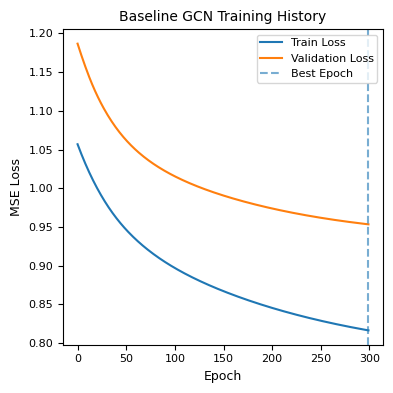

In [17]:
#| label: fig-gcn-training-history
#| fig-cap: "Training and validation loss curves for the baseline GCN model."

# Convert the saved training history to a DataFrame for plotting
history_df = baseline_gcn_results["history_df"]

best_epoch = baseline_gcn_results["history"].best_epoch

# Plot train and validation loss across epochs
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

# Mark best validation epoch
ax.axvline(best_epoch, linestyle="--", alpha=0.6, label="Best Epoch")

ax.set_title("Baseline GCN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [18]:
#| label: tbl-gcn-baseline-results
#| tbl-cap: "Baseline GCN validation results for predicting log1p(FEMA IHP). Performance is summarized using validation RMSE and $R^2$."
#| output: false

gcn_baseline_summary = pd.DataFrame(
    {
        "Number of Layers": [baseline_gcn_results["config"]["num_layers"]],
        "Hidden Dimension": [baseline_gcn_results["config"]["hidden_dim"]],
        "Dropout": [baseline_gcn_results["config"]["dropout"]],
        "Weight Decay": [baseline_gcn_results["config"]["weight_decay"]],
        "Learning Rate": [baseline_gcn_results["config"]["lr"]],
        "Trainable Parameters": [baseline_gcn_results["config"]["n_parameters"]],
        "Epochs Trained": [len(baseline_gcn_results["history"].train_loss)],
        "Best Epoch": [baseline_gcn_results["history"].best_epoch],
        "Best Validation Loss": [baseline_gcn_results["history"].best_val_loss],
        "Validation RMSE": [float(baseline_gcn_results["val_metrics"]["RMSE"].iloc[0])],
        "Validation R²": [float(baseline_gcn_results["val_metrics"]["R2"].iloc[0])],
    }
)

gcn_baseline_summary["Best Validation Loss"] = gcn_baseline_summary["Best Validation Loss"].round(6)
gcn_baseline_summary["Validation RMSE"] = gcn_baseline_summary["Validation RMSE"].round(6)
gcn_baseline_summary["Validation R²"] = gcn_baseline_summary["Validation R²"].round(6)

gcn_baseline_summary["Experiment"] = ["Baseline GCN"]

gcn_baseline_summary = gcn_baseline_summary.set_index("Experiment").T

display(gcn_baseline_summary)

Experiment,Baseline GCN
Number of Layers,1.000000
Hidden Dimension,64.000000
Dropout,0.100000
Weight Decay,0.000010
Learning Rate,0.001000
Trainable Parameters,16.000000
Epochs Trained,300.000000
Best Epoch,299.000000
Best Validation Loss,0.953363
Validation RMSE,2.760142


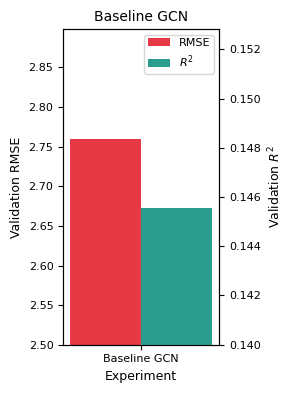

In [19]:
#| label: fig-gcn-baseline-performance
#| fig-cap: "Validation performance for the baseline GCN model predicting log1p(FEMA IHP). RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy on the validation split."

rmse_vals = [float(baseline_gcn_results["val_metrics"]["RMSE"].iloc[0])]
r2_vals = [float(baseline_gcn_results["val_metrics"]["R2"].iloc[0])]

experiments = ["Baseline GCN"]
x = np.arange(len(experiments))
width = 0.35

rmse_ylim = (2.5)
r2_ylim = (0.14)

fig, ax = plt.subplots(figsize=(3, 4))

bars1 = ax.bar(
    x - width / 2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax.set_ylabel("Validation RMSE")
ax.set_xticks(x)
ax.set_xticklabels(experiments)
ax.set_xlabel("Experiment")
ax.set_title("Baseline GCN")

if rmse_ylim is not None:
    ax.set_ylim(rmse_ylim)

ax2 = ax.twinx()

bars2 = ax2.bar(
    x + width / 2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

ax.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Layer Ablation

The effect of GCN depth was evaluated by varying the number of graph convolution layers ($\text{num\_layers} = 1, 2, 3$) while holding all other hyperparameters fixed. The results are summarized in @tbl-gcn-layer-ablation and visualized in @fig-gcn-layer-ablation.

Increasing the model depth from one to two layers substantially improved performance. The single-layer model achieved a validation RMSE of $2.760$ and $R^2 = 0.145$, while the two-layer model reduced RMSE to $2.449$ and increased $R^2$ to $0.327$. This improvement indicates that incorporating information from two-hop neighborhoods helps capture broader spatial relationships between counties. Adding a third layer did not improve performance. The three-layer model produced a slightly higher RMSE of $2.481$ and a lower $R^2$ of $0.309$, suggesting diminishing returns as depth increases. Overall, the two-layer GCN achieved the best validation performance and was selected as the base architecture for subsequent ablation experiments.

In [20]:
#| label: tbl-gcn-layer-ablation-grid
#| tbl-cap: "Layer configurations evaluated in the first GCN ablation stage."
#| output: false

layer_candidates = [1, 2, 3]

layer_ablation_df = pd.DataFrame({"num_layers": layer_candidates})
display(layer_ablation_df.style.hide(axis="index"))

num_layers
1
2
3


In [21]:
#| output: false

layer_results = []

for num_layers in layer_candidates:

    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=base_gcn_config["hidden_dim"],
        num_layers=num_layers,
        dropout=base_gcn_config["dropout"],
        lr=base_gcn_config["lr"],
        weight_decay=base_gcn_config["weight_decay"],
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=["log1p_total_ihp"],
        scaler_y=scaler_ylog,
        verbose=False,
        evaluate_test=False,
    )

    layer_results.append(
        {
            "Number of Layers": num_layers,
            "Validation RMSE": float(result["val_metrics"]["RMSE"].iloc[0]),
            "Validation R²": float(result["val_metrics"]["R2"].iloc[0]),
        }
    )

In [22]:
#| label: tbl-gcn-layer-ablation
#| tbl-cap: "Layer ablation results for the GCN model predicting log1p(FEMA IHP). Performance is summarized using validation RMSE and $R^2$."

layer_results_df = pd.DataFrame(layer_results)

layer_summary = layer_results_df[
    [
        "Number of Layers",
        "Validation RMSE",
        "Validation R²",
    ]
].copy()

layer_summary["Validation RMSE"] = layer_summary["Validation RMSE"].round(6)
layer_summary["Validation R²"] = layer_summary["Validation R²"].round(6)

layer_summary["Experiment"] = (
    "Layers=" + layer_summary["Number of Layers"].astype(str)
)

layer_summary = layer_summary.drop(columns=["Number of Layers"])
layer_summary = layer_summary.set_index("Experiment").T

display(layer_summary)

Experiment,Layers=1,Layers=2,Layers=3
Validation RMSE,2.760142,2.449203,2.481415
Validation R²,0.145534,0.327207,0.309394


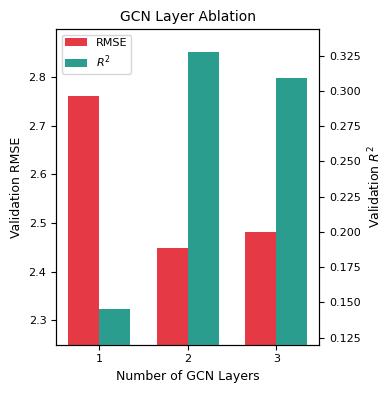

In [23]:
#| label: fig-gcn-layer-ablation
#| fig-cap: "Validation performance across different GCN layer depths when predicting log1p(FEMA IHP). RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy on the validation split."

layers = layer_results_df["Number of Layers"].values
rmse_vals = layer_results_df["Validation RMSE"].values
r2_vals = layer_results_df["Validation R²"].values

x = np.arange(len(layers))
width = 0.35

rmse_ylim = (2.25)
r2_ylim = (.12)

fig, ax1 = plt.subplots(figsize=(4,4))

# RMSE bars
bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(layers)
ax1.set_xlabel("Number of GCN Layers")
ax1.set_title("GCN Layer Ablation")

if rmse_ylim is not None:
    ax1.set_ylim(rmse_ylim)

# R² bars
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

# Legend
ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [24]:
# Select the best layer configuration using validation RMSE
best_num_layers = int(
    layer_results_df.loc[
        layer_results_df["Validation RMSE"].idxmin(),
        "Number of Layers"
    ]
)

# Update base configuration with the best number of layers
base_gcn_config["num_layers"] = best_num_layers

## Hidden Dimension Ablation

The hidden dimension ablation evaluates how the width of the GCN representation affects predictive performance while holding all other hyperparameters fixed. The results are summarized in @tbl-gcn-hidden-ablation-results and visualized in @fig-gcn-hidden-ablation.

Increasing the hidden dimension consistently improved performance. Expanding the model from $32$ to $64$ hidden units reduced validation RMSE from $2.490$ to $2.449$ and increased $R^2$ from $0.305$ to $0.327$. Further increasing the hidden dimension to $128$ produced the best performance, lowering RMSE to $2.424$ and increasing $R^2$ to $0.341$.

These results indicate that a wider hidden representation allows the GCN to learn richer spatial feature transformations from the socioeconomic predictors. The $128$-dimensional configuration achieved the best validation performance and was therefore selected as the hidden dimension for the final model configuration.

In [25]:
#| label: tbl-gcn-hidden-ablation-grid
#| tbl-cap: "Hidden dimension configurations evaluated in the second GCN ablation stage."
#| output: false

hidden_candidates = [32, 64, 128]

hidden_ablation_df = pd.DataFrame({"hidden_dim": hidden_candidates})
display(hidden_ablation_df.style.hide(axis="index"))

hidden_dim
32
64
128


In [26]:
#| output: false

hidden_results = []

for hidden_dim in hidden_candidates:

    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=hidden_dim,
        num_layers=best_num_layers,
        dropout=base_gcn_config["dropout"],
        lr=base_gcn_config["lr"],
        weight_decay=base_gcn_config["weight_decay"],
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=["log1p_total_ihp"],
        scaler_y=scaler_ylog,
        verbose=False,
        evaluate_test=False,
    )

    hidden_results.append(
        {
            "Hidden Dimension": hidden_dim,
            "Validation RMSE": float(result["val_metrics"]["RMSE"].iloc[0]),
            "Validation R²": float(result["val_metrics"]["R2"].iloc[0]),
        }
    )

In [27]:
#| label: tbl-gcn-hidden-ablation-results
#| tbl-cap: "Hidden dimension ablation results for the GCN using the best layer configuration from the previous stage. Performance is summarized using validation RMSE and $R^2$ for predicting log1p(FEMA IHP)."

hidden_results_df = (
    pd.DataFrame(hidden_results)
    .sort_values("Hidden Dimension")
    .reset_index(drop=True)
)

display(hidden_results_df.style.hide(axis="index"))

Hidden Dimension,Validation RMSE,Validation R²
32,2.490122,0.304539
64,2.449203,0.327207
128,2.423884,0.341045


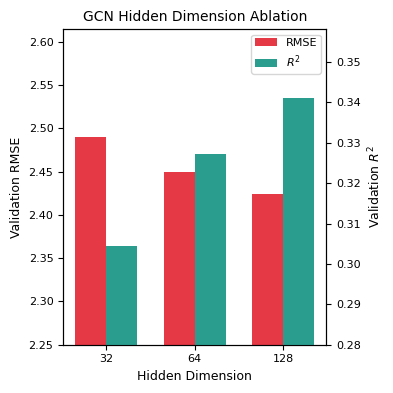

In [28]:
#| label: fig-gcn-hidden-ablation
#| fig-cap: "Validation performance across different GCN hidden dimensions using the best layer configuration. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

hidden_dims = hidden_results_df["Hidden Dimension"].values
rmse_vals = hidden_results_df["Validation RMSE"].values
r2_vals = hidden_results_df["Validation R²"].values

x = np.arange(len(hidden_dims))
width = 0.35

rmse_ylim = (2.25)
r2_ylim = (0.28)

fig, ax1 = plt.subplots(figsize=(4,4))

# RMSE bars
bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(hidden_dims)
ax1.set_xlabel("Hidden Dimension")
ax1.set_title("GCN Hidden Dimension Ablation")

if rmse_ylim is not None:
    ax1.set_ylim(rmse_ylim)

# R² bars
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

# Legend
ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [29]:
# Select the best hidden dimension based on validation RMSE
best_hidden_dim = int(
    hidden_results_df.loc[
        hidden_results_df["Validation RMSE"].idxmin(),
        "Hidden Dimension"
    ]
)

# Update base configuration with the best hidden dimension
base_gcn_config["hidden_dim"] = best_hidden_dim

## Regularization Ablation

### Weight Decay Ablation

The effect of L2 regularization was evaluated by varying the weight decay parameter while keeping the selected architecture (two GCN layers and a $128$-dimensional hidden representation) fixed. The results are summarized in @tbl-gcn-weight-decay-results and visualized in @fig-gcn-weight-decay-ablation.

Model performance was relatively stable across the tested weight decay values. The configuration without regularization ($0$) and the very small penalty ($10^{-5}$) produced nearly identical results, both achieving a validation RMSE of approximately $2.418$ and an $R^2$ of about $0.344$. Increasing the regularization strength to $10^{-3}$ slightly degraded performance, increasing RMSE to $2.424$ and reducing $R^2$ to $0.341$.

These results suggest that strong regularization is not necessary for this model configuration. The smallest non-zero value ($10^{-5}$) achieved the best validation RMSE while maintaining stable $R^2$, and was therefore selected as the final weight decay setting for the GCN model.

In [30]:
#| label: tbl-gcn-weight-decay-grid
#| tbl-cap: "Weight decay configurations evaluated in the GCN regularization ablation."
#| output: false

weight_decay_candidates = [0.0,  1e-5, 1e-3]

weight_decay_df = pd.DataFrame({"weight_decay": weight_decay_candidates})
display(weight_decay_df.style.format({"weight_decay": "{:.0e}"}).hide(axis="index"))

weight_decay
0e+00
1e-05
1e-03


In [31]:
#| output: false

weight_decay_results = []

for wd in weight_decay_candidates:

    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=best_hidden_dim,
        num_layers=best_num_layers,
        dropout=0.0,
        lr=base_gcn_config["lr"],
        weight_decay=wd,
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=["log1p_total_ihp"],
        scaler_y=scaler_ylog,
        verbose=False,
        evaluate_test=False,
    )

    weight_decay_results.append(
        {
            "Weight Decay": wd,
            "Validation RMSE": float(result["val_metrics"]["RMSE"].iloc[0]),
            "Validation R²": float(result["val_metrics"]["R2"].iloc[0]),
        }
    )

In [32]:
#| label: tbl-gcn-weight-decay-results
#| tbl-cap: "Weight decay ablation results for the GCN using the selected layer depth and hidden dimension. Performance is summarized using validation RMSE and $R^2$ for predicting log1p(FEMA IHP)."

weight_decay_results_df = (
    pd.DataFrame(weight_decay_results)
    .sort_values("Weight Decay")
    .reset_index(drop=True)
)

display(
    weight_decay_results_df
    .style
    .format({"Weight Decay": "{:.0e}"})
    .hide(axis="index")
)

Weight Decay,Validation RMSE,Validation R²
0e+00,2.417776,0.344362
1e-05,2.417614,0.344450
1e-03,2.423875,0.341050


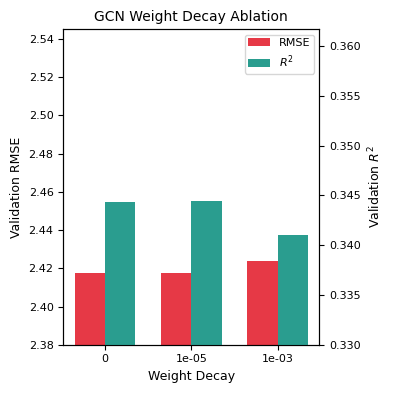

In [33]:
#| label: fig-gcn-weight-decay-ablation
#| fig-cap: "Validation performance across weight decay strengths using the selected GCN architecture. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

wd_vals = weight_decay_results_df["Weight Decay"].values
rmse_vals = weight_decay_results_df["Validation RMSE"].values
r2_vals = weight_decay_results_df["Validation R²"].values

x = np.arange(len(wd_vals))
width = 0.35

rmse_ylim = (2.38)
r2_ylim = (0.33)

fig, ax1 = plt.subplots(figsize=(4,4))

# RMSE bars
bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)

labels = ["0" if v == 0 else f"{v:.0e}" for v in wd_vals]
ax1.set_xticklabels(labels)

ax1.set_xlabel("Weight Decay")
ax1.set_title("GCN Weight Decay Ablation")

if rmse_ylim is not None:
    ax1.set_ylim(rmse_ylim)

# R² bars
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

# Legend
ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [34]:
# Select the best weight decay based on validation RMSE
best_weight_decay = float(
    weight_decay_results_df.loc[
        weight_decay_results_df["Validation RMSE"].idxmin(),
        "Weight Decay"
    ]
)

# Update base configuration with the best weight decay
base_gcn_config["weight_decay"] = best_weight_decay

### Dropout Ablation

The effect of dropout regularization was evaluated by varying the dropout probability while keeping the selected architecture (two GCN layers, hidden dimension of $128$, and weight decay of $10^{-5}$) fixed. The results are summarized in @tbl-gcn-dropout-results and visualized in @fig-gcn-dropout-ablation.

The model achieved the best validation performance without dropout. With dropout set to $0$, the model obtained a validation RMSE of $2.418$ and an $R^2$ of $0.344$. Introducing dropout slightly degraded performance: a dropout rate of $0.1$ increased RMSE to $2.424$ and reduced $R^2$ to $0.341$, while a higher dropout rate of $0.3$ further increased RMSE to $2.429$ and reduced $R^2$ to $0.338$.

These results suggest that dropout does not provide a benefit for this configuration. Because the dataset is relatively small and the selected GCN architecture is modest in size, additional stochastic regularization appears unnecessary. Consequently, a dropout value of $0$ was selected for the final GCN configuration.

In [35]:
#| label: tbl-gcn-dropout-grid
#| tbl-cap: "Dropout configurations evaluated after selecting the best weight decay."
#| output: false

dropout_candidates = [0.0, 0.1, 0.3]

dropout_df = pd.DataFrame({"dropout": dropout_candidates})
display(dropout_df.style.format({"dropout": "{:.1e}"}).hide(axis="index"))

dropout
0.0e+00
1.0e-01
3.0e-01


In [36]:
#| output: false

dropout_results = []

for dropout in dropout_candidates:

    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=best_hidden_dim,
        num_layers=best_num_layers,
        dropout=dropout,
        lr=base_gcn_config["lr"],
        weight_decay=best_weight_decay,
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=["log1p_total_ihp"],
        scaler_y=scaler_ylog,
        verbose=False,
        evaluate_test=False,
    )

    dropout_results.append(
        {
            "Dropout": dropout,
            "Validation RMSE": float(result["val_metrics"]["RMSE"].iloc[0]),
            "Validation R²": float(result["val_metrics"]["R2"].iloc[0]),
        }
    )

In [37]:
#| label: tbl-gcn-dropout-results
#| tbl-cap: "Dropout ablation results for the GCN using the selected architecture and weight decay. Performance is summarized using validation RMSE and $R^2$ for predicting log1p(FEMA IHP)."

dropout_results_df = (
    pd.DataFrame(dropout_results)
    .sort_values("Dropout")
    .reset_index(drop=True)
)

display(
    dropout_results_df
    .style
    .format({"Dropout": "{:.1e}"})
    .hide(axis="index")
)

Dropout,Validation RMSE,Validation R²
0.0e+00,2.417614,0.344450
1.0e-01,2.423884,0.341045
3.0e-01,2.429440,0.338021


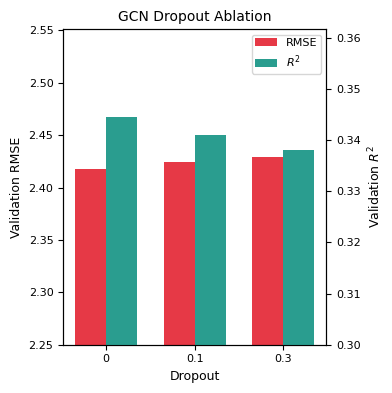

In [38]:
#| label: fig-gcn-dropout-ablation
#| fig-cap: "Validation performance across dropout probabilities using the selected GCN architecture. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

drop_vals = dropout_results_df["Dropout"].values
rmse_vals = dropout_results_df["Validation RMSE"].values
r2_vals = dropout_results_df["Validation R²"].values

x = np.arange(len(drop_vals))
width = 0.35

rmse_ylim = (2.25)
r2_ylim = (0.3)

fig, ax1 = plt.subplots(figsize=(4,4))

bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)

labels = ["0" if v == 0 else f"{v:.1f}" for v in drop_vals]
ax1.set_xticklabels(labels)

ax1.set_xlabel("Dropout")
ax1.set_title("GCN Dropout Ablation")

if rmse_ylim is not None:
    ax1.set_ylim(rmse_ylim)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [39]:
# Select the best dropout using validation RMSE
best_dropout = float(
    dropout_results_df.loc[
        dropout_results_df["Validation RMSE"].idxmin(),
        "Dropout"
    ]
)

# Update base configuration with the best dropout
base_gcn_config["dropout"] = best_dropout

## GCN Experimental Results

In the end, the ablation experiments identified the best GCN configuration using log-transformed features, the 2-layer with 128 hidden dimensions, dropout = 0.0, and weight decay = 1e-5. This model achieved the best validation performance (RMSE) and was selected as the graph-based benchmark for predicting `log1p(FEMA IHP)`. The final held-out test evaluation shows relatively lower predictive performance compared to the MLP, with test RMSE = 2.4050 and $R^2$ = 0.3829 as shown in Table 9.1 below.

An important finding from the experimental results is the discrepancy in computational efficiency and convergence between the tabular and spatial architectures. The final MLP baseline, containing 12,417 trainable parameters, converged optimally at epoch 21. In contrast, the best-performing GCN model contained only 2,177 parameters but required the full 300 epochs to reach its best validation state. Despite having approximately 82% fewer parameters, the spatial model required substantially more training time and still underperformed the tabular baseline. This suggests that propagating features through the Queen contiguity graph introduced noise rather than predictive signal, forcing the network to optimize over a more complex, less informative loss landscape.

# Final Model Comparisons

@tbl-mlp-gcn-comparison and @fig-mlp-gcn-overall-comparison summarize the final held-out test performance of the final multilayer perceptron (MLP) baseline and the final graph convolutional network (GCN). For both models, the best-performing hyperparameter configuration identified during the ablation experiments was selected and then retrained using the full training data before being evaluated on the held-out test set. This ensures that the reported results reflect the strongest configuration discovered during model development while maintaining a strict separation between model selection and final evaluation.

On the held-out test set, the MLP achieved a **test RMSE of 2.00** and an **$R^2$ of 0.571**, indicating that the model explains approximately **57% of the variance** in the log-transformed FEMA IHP outcome. These results suggest that nonlinear interactions among the SVI indicators provide meaningful predictive signal for disaster assistance outcomes. On the test set, the model achieved a **test RMSE of 2.40** and an **$R^2$ of 0.397**, explaining roughly **40% of the variance** in the target variable.

In [40]:
# Best gcn config
final_gcn_config = {
    "num_layers": best_num_layers,
    "hidden_dim": best_hidden_dim,
    "weight_decay": best_weight_decay,
    "dropout": best_dropout,
    "lr": base_gcn_config["lr"],
    "n_epochs": base_gcn_config["n_epochs"],
    "patience": base_gcn_config["patience"],
    "seed": base_gcn_config["seed"],
}

In [41]:
#| output: false

# Run the final GCN using the selected configuration on held-out test set
final_gcn_results = run_gcn_experiment(
    adjacency=adjacency_torch,
    X=X_t,
    y=y_t,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    hidden_dim=final_gcn_config["hidden_dim"],
    num_layers=final_gcn_config["num_layers"],
    dropout=final_gcn_config["dropout"],
    lr=final_gcn_config["lr"],
    weight_decay=final_gcn_config["weight_decay"],
    n_epochs=final_gcn_config["n_epochs"],
    patience=final_gcn_config["patience"],
    seed=final_gcn_config["seed"],
    target_names=["log1p_total_ihp"],
    scaler_y=scaler_ylog,
    verbose=False,
    evaluate_test=True,
)

In [42]:
#| label: tbl-mlp-gcn-comparison
#| tbl-cap: "Configuration and test-set comparison between the final MLP baseline and the final GCN model."

# Extract from configs
mlp_row = mlp_config_df.iloc[0]
gcn_cfg = final_gcn_results["config"]
gcn_history_df = final_gcn_results["history_df"]
gcn_test_metrics = final_gcn_results["test_metrics"].iloc[0]

# Calculate GCN # of params
gcn_trainable_params = sum(
    p.numel() for p in final_gcn_results["model"].parameters() if p.requires_grad
)
# Calculate epochs & val_loss
gcn_epochs_trained = len(gcn_history_df)
gcn_best_epoch = int(gcn_history_df["val_loss"].idxmin()) + 1
gcn_best_val_loss = float(gcn_history_df["val_loss"].min())

model_comparison_df = pd.DataFrame(
    {
        "Metric": [
            "Feature Pipeline",
            "Architecture",
            "Hidden Dimensions",
            "Dropout",
            "Weight Decay",
            "Learning Rate",
            "Trainable Parameters",
            "Epochs Trained",
            "Best Epoch",
            "Best Validation Loss",
            "Test RMSE",
            "Test R²",
        ],
        "MLP": [
            mlp_row["Feature Pipeline"],
            mlp_row["Architecture"],
            mlp_row["Hidden Dimensions"],
            mlp_row["Dropout"],
            mlp_row["Weight Decay"],
            mlp_row["Learning Rate"],
            mlp_row["Trainable Parameters"],
            mlp_row["Epochs Trained"],
            mlp_row["Best Epoch"],
            mlp_row["Best Validation Loss"],
            mlp_row["Test RMSE"],
            mlp_row["Test R²"],
        ],
        "GCN": [
            "Log-Transformed Features",
            f'GCN ({gcn_cfg["num_layers"]} layers)',
            gcn_cfg["hidden_dim"],
            gcn_cfg["dropout"],
            gcn_cfg["weight_decay"],
            gcn_cfg["lr"],
            gcn_trainable_params,
            gcn_epochs_trained,
            gcn_best_epoch,
            gcn_best_val_loss,
            gcn_test_metrics["RMSE"],
            gcn_test_metrics["R2"],
        ],
    }
)

display(model_comparison_df.style.hide(axis="index"))

Metric,MLP,GCN
Feature Pipeline,Log-Transformed Features,Log-Transformed Features
Architecture,Deep-128,GCN (2 layers)
Hidden Dimensions,"[128, 64, 32]",128
Dropout,0.100000,0.000000
Weight Decay,0.000010,0.000010
Learning Rate,0.001000,0.001000
Trainable Parameters,12417,2177
Epochs Trained,46,300
Best Epoch,21,300
Best Validation Loss,0.459419,0.731424


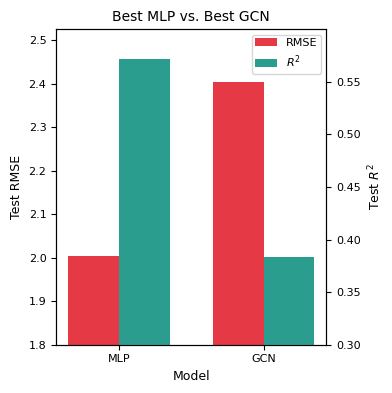

In [43]:
#| label: fig-mlp-gcn-overall-comparison
#| fig-cap: "Overall held-out test-set comparison between the best MLP baseline and the final GCN model. RMSE (left axis) and $R^2$ (right axis) summarize predictive accuracy for log1p(FEMA IHP)."

rmse_row = model_comparison_df.loc[model_comparison_df["Metric"] == "Test RMSE"].iloc[0]
r2_row = model_comparison_df.loc[model_comparison_df["Metric"] == "Test R²"].iloc[0]

models = np.array(["MLP", "GCN"])
rmse_vals = np.array([rmse_row["MLP"], rmse_row["GCN"]], dtype=float)
r2_vals = np.array([r2_row["MLP"], r2_row["GCN"]], dtype=float)

x = np.arange(len(models))
width = 0.35

rmse_ylim = (1.8)
r2_ylim = (0.3)

fig, ax1 = plt.subplots(figsize=(4,4))

bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Test RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_xlabel("Model")
ax1.set_title("Best MLP vs. Best GCN")

if rmse_ylim is not None:
    ax1.set_ylim(rmse_ylim)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Test $R^2$")

if r2_ylim is not None:
    ax2.set_ylim(r2_ylim)

ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()